In [37]:
import pandas as pd
import numpy as np

from matplotlib import pyplot as plt
from scipy import stats

In [38]:
root = "C:/Users/P70099789/OneDrive - Maastricht University/Documents/GitHub/games-and-genes/"

df_expression = pd.read_table(f"{root}data/E-MTAB-6698/esets_colorectal_exprs_genes.txt", index_col=0, sep="\t")
df_samples = pd.read_table(f"{root}data/E-MTAB-6698/E-MTAB-6698.sdrf.txt", index_col=0, sep="\t")

In [39]:
print(df_expression.shape)
df_expression.head()

(20545, 1566)


,GSM93789.CEL,GSM93920.CEL,GSM93921.CEL,GSM93922.CEL,GSM93923.CEL,GSM93924.CEL,GSM93925.CEL,GSM93926.CEL,GSM93927.CEL,GSM93928.CEL,...,GSM656863.CEL,GSM656864.CEL,GSM656865.CEL,GSM656866.CEL,GSM656867.CEL,GSM656868.CEL,GSM656869.CEL,GSM656870.CEL,GSM656871.CEL,GSM656872.CEL
RFC2,7.929677,7.854143,7.308270,6.950234,7.652556,8.261547,7.771710,7.944700,7.716508,8.199637,...,8.223763,7.984917,7.452004,7.887050,8.148251,8.214854,7.844366,7.879769,7.399942,7.824952
HSPA6,7.244958,6.259710,5.627952,6.627430,7.215147,7.923059,6.115572,7.003219,7.773903,7.178106,...,5.571035,7.899233,5.601556,6.039910,5.746308,6.640617,5.639763,9.657426,6.683036,6.026434
PAX8,8.045324,8.836362,8.265764,8.172837,8.169475,7.804495,7.855919,7.875820,8.165360,8.561437,...,8.531618,8.446917,7.766118,8.511495,8.039585,8.252693,8.096580,8.243897,7.980497,8.381846
GUCA1A,6.906669,5.954986,6.185210,6.169518,6.052645,6.374832,6.277351,6.047262,6.211682,6.326460,...,6.277168,5.770019,6.169756,6.397584,6.173429,6.095867,6.391574,6.294047,6.020007,6.253102
THRA,6.777595,7.498451,6.805277,7.178793,7.182048,7.025079,8.044426,7.447724,6.640333,7.698765,...,6.972926,7.250965,7.414589,6.791696,7.092685,7.228828,7.219180,7.696593,6.803251,7.256877


In [40]:
print(df_samples.shape)
df_samples.head()

(1566, 39)


,Characteristics[organism],Characteristics[disease],Characteristics[GEO accession number],Characteristics[sex],Characteristics[age],Unit[time unit],Characteristics[stage],Characteristics[grade],Characteristics[tumor content],Characteristics[overall survival (months)],...,Assay Name,Technology Type,Array Design REF,Term Source REF,Protocol REF.4,Protocol REF.5,Derived Array Data File,Comment [Derived ArrayExpress FTP file],Factor Value[disease],Factor Value[macro/microdissection]
Source Name,,,,,,,,,,,,,,,,,,,,,
GSM437217.CEL,Homo sapiens,tumor,GSE17536,male,26,year,3.0,2 - Moderately differentiated (MD),NaN,50.43,...,GSM437217.CEL:biotin,array assay,A-AFFY-44,ArrayExpress,P-MTAB-74103,P-MTAB-74104,esets_colorectal_exprs_genes.txt,ftp://ftp.ebi.ac.uk/pub/databases/microarray/d...,tumor,Macrodissected
GSM437155.CEL,Homo sapiens,tumor,GSE17536,Female,38,year,2.0,2 - Moderately differentiated (MD),NaN,37.67,...,GSM437155.CEL:biotin,array assay,A-AFFY-44,ArrayExpress,P-MTAB-74103,P-MTAB-74104,esets_colorectal_exprs_genes.txt,ftp://ftp.ebi.ac.uk/pub/databases/microarray/d...,tumor,Macrodissected
GSM437175.CEL,Homo sapiens,tumor,GSE17536,male,39,year,3.0,2 - Moderately differentiated (MD),NaN,105.17,...,GSM437175.CEL:biotin,array assay,A-AFFY-44,ArrayExpress,P-MTAB-74103,P-MTAB-74104,esets_colorectal_exprs_genes.txt,ftp://ftp.ebi.ac.uk/pub/databases/microarray/d...,tumor,Macrodissected
GSM437171.CEL,Homo sapiens,tumor,GSE17536,Female,40,year,2.0,1 - Well differentiated (WD),NaN,8.38,...,GSM437171.CEL:biotin,array assay,A-AFFY-44,ArrayExpress,P-MTAB-74103,P-MTAB-74104,esets_colorectal_exprs_genes.txt,ftp://ftp.ebi.ac.uk/pub/databases/microarray/d...,tumor,Macrodissected
GSM437222.CEL,Homo sapiens,tumor,GSE17536,male,41,year,3.0,2 - Moderately differentiated (MD),NaN,63.05,...,GSM437222.CEL:biotin,array assay,A-AFFY-44,ArrayExpress,P-MTAB-74103,P-MTAB-74104,esets_colorectal_exprs_genes.txt,ftp://ftp.ebi.ac.uk/pub/databases/microarray/d...,tumor,Macrodissected


In [41]:
disease = df_samples["Characteristics[disease]"]
stage = df_samples["Characteristics[stage]"]

df_samples = df_samples[disease.isin(["normal", "tumor"])].copy()
disease = df_samples["Characteristics[disease]"]
stage = df_samples["Characteristics[stage]"]

df_samples = df_samples[
    (disease != "tumor") | stage.notna()
].copy()

df_samples.loc[df_samples["Characteristics[disease]"] != "tumor", "Characteristics[stage]"] = 0

print(df_samples.shape)

(443, 39)


In [42]:
df_expression = df_expression.loc[:, df_expression.columns.intersection(df_samples.index)]
print(df_expression.shape)

(20545, 443)


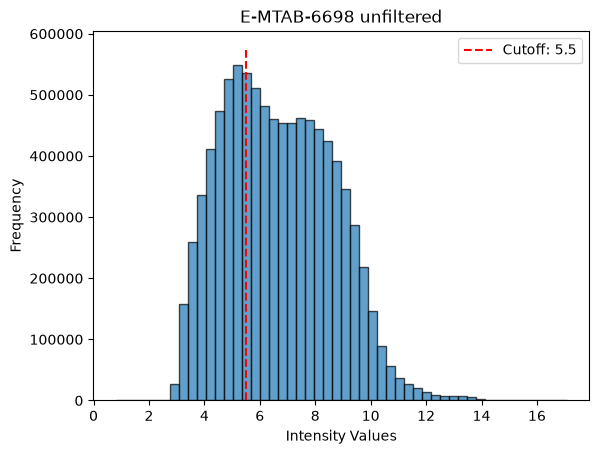

In [43]:
flat_data = df_expression.to_numpy().flatten()

cutoff = 5.5

plt.hist(flat_data, bins=50, edgecolor='black', alpha=0.7)
plt.vlines(cutoff, ymin=0, ymax=plt.ylim()[1], colors='red', linestyles='dashed', label=f'Cutoff: {cutoff}')
plt.title('E-MTAB-6698 unfiltered')
plt.xlabel('Intensity Values')
plt.ylabel('Frequency')
plt.legend()
plt.show()

In [44]:
min_intensities = df_expression.min(axis=1)
df_expression_filtered = df_expression[min_intensities > cutoff]
print(df_expression_filtered.shape)

(8619, 443)


C:\Users\P70099789\AppData\Local\Temp\ipykernel_26816\3475150019.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


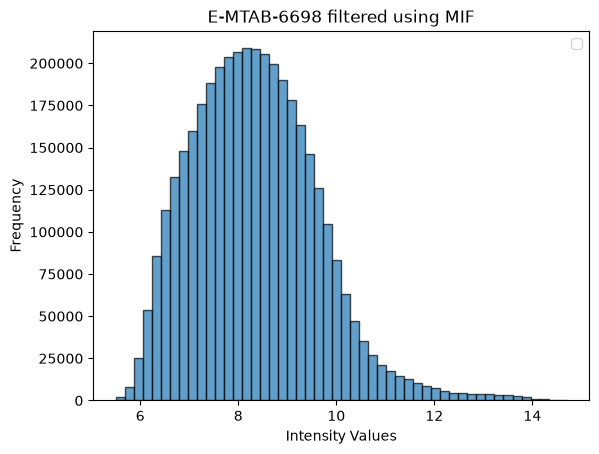

In [45]:
flat_data_filtered = df_expression_filtered.to_numpy().flatten()

plt.hist(flat_data_filtered, bins=50, edgecolor='black', alpha=0.7)
plt.title('E-MTAB-6698 filtered using MIF')
plt.xlabel('Intensity Values')
plt.ylabel('Frequency')
plt.legend()
plt.show()

In [46]:
k = 2500  # set the desired number of genes

gene_mad = (
    df_expression_filtered.sub(df_expression_filtered.median(axis=1), axis=0)
    .abs()
    .median(axis=1)
)

top_genes = gene_mad.nlargest(k).index
df_expression_filtered = df_expression_filtered.loc[top_genes]

print(df_expression_filtered.shape)

(2500, 443)


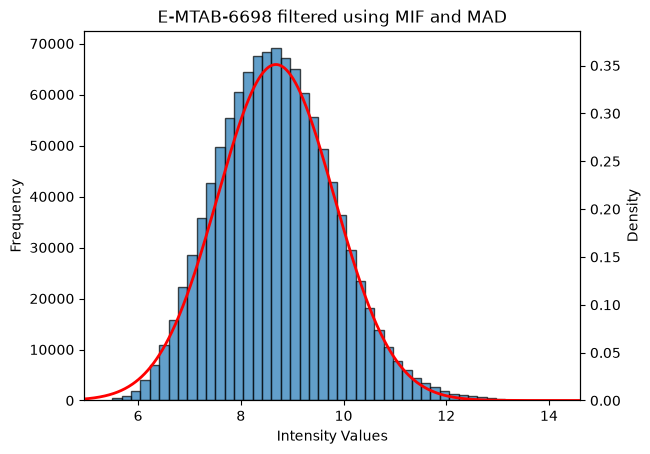

In [47]:
flat_data_filtered = df_expression_filtered.to_numpy().flatten()

x_curve = np.linspace(0, np.max(flat_data_filtered), 1000)
y_curve = stats.norm.pdf(x_curve, np.mean(flat_data_filtered), np.std(flat_data_filtered))

fig, ax1 = plt.subplots()
ax2 = ax1.twinx()

ax1.hist(flat_data_filtered, bins=50, edgecolor='black', alpha=0.7)
ax2.plot(x_curve, y_curve, 'r-', linewidth=2)

ax1.set_xlabel('Intensity Values')
ax1.set_ylabel('Frequency')
ax2.set_ylabel('Density')
ax1.set_xlim(np.min(flat_data_filtered) * 0.9, np.max(x_curve))
ax2.set_ylim(0, np.max(y_curve) * 1.1)
ax1.set_title('E-MTAB-6698 filtered using MIF and MAD')

plt.show()

In [48]:
df_expression_filtered.to_csv(f"{root}data/E-MTAB-6698_filtered_MIF_MAD/processed/expression_filtered.csv", index=True)
df_samples.to_csv(f"{root}data/E-MTAB-6698_filtered_MIF_MAD/processed/samples.csv", index=True)

In [49]:
df_samples.head()

,Characteristics[organism],Characteristics[disease],Characteristics[GEO accession number],Characteristics[sex],Characteristics[age],Unit[time unit],Characteristics[stage],Characteristics[grade],Characteristics[tumor content],Characteristics[overall survival (months)],...,Assay Name,Technology Type,Array Design REF,Term Source REF,Protocol REF.4,Protocol REF.5,Derived Array Data File,Comment [Derived ArrayExpress FTP file],Factor Value[disease],Factor Value[macro/microdissection]
Source Name,,,,,,,,,,,,,,,,,,,,,
GSM437217.CEL,Homo sapiens,tumor,GSE17536,male,26,year,3.0,2 - Moderately differentiated (MD),NaN,50.43,...,GSM437217.CEL:biotin,array assay,A-AFFY-44,ArrayExpress,P-MTAB-74103,P-MTAB-74104,esets_colorectal_exprs_genes.txt,ftp://ftp.ebi.ac.uk/pub/databases/microarray/d...,tumor,Macrodissected
GSM437155.CEL,Homo sapiens,tumor,GSE17536,Female,38,year,2.0,2 - Moderately differentiated (MD),NaN,37.67,...,GSM437155.CEL:biotin,array assay,A-AFFY-44,ArrayExpress,P-MTAB-74103,P-MTAB-74104,esets_colorectal_exprs_genes.txt,ftp://ftp.ebi.ac.uk/pub/databases/microarray/d...,tumor,Macrodissected
GSM437175.CEL,Homo sapiens,tumor,GSE17536,male,39,year,3.0,2 - Moderately differentiated (MD),NaN,105.17,...,GSM437175.CEL:biotin,array assay,A-AFFY-44,ArrayExpress,P-MTAB-74103,P-MTAB-74104,esets_colorectal_exprs_genes.txt,ftp://ftp.ebi.ac.uk/pub/databases/microarray/d...,tumor,Macrodissected
GSM437171.CEL,Homo sapiens,tumor,GSE17536,Female,40,year,2.0,1 - Well differentiated (WD),NaN,8.38,...,GSM437171.CEL:biotin,array assay,A-AFFY-44,ArrayExpress,P-MTAB-74103,P-MTAB-74104,esets_colorectal_exprs_genes.txt,ftp://ftp.ebi.ac.uk/pub/databases/microarray/d...,tumor,Macrodissected
GSM437222.CEL,Homo sapiens,tumor,GSE17536,male,41,year,3.0,2 - Moderately differentiated (MD),NaN,63.05,...,GSM437222.CEL:biotin,array assay,A-AFFY-44,ArrayExpress,P-MTAB-74103,P-MTAB-74104,esets_colorectal_exprs_genes.txt,ftp://ftp.ebi.ac.uk/pub/databases/microarray/d...,tumor,Macrodissected


In [50]:
df_samples_rand = df_samples.copy()
df_samples_rand["Characteristics[disease]"] = np.random.permutation(df_samples_rand["Characteristics[disease]"])
df_samples_rand.head()

,Characteristics[organism],Characteristics[disease],Characteristics[GEO accession number],Characteristics[sex],Characteristics[age],Unit[time unit],Characteristics[stage],Characteristics[grade],Characteristics[tumor content],Characteristics[overall survival (months)],...,Assay Name,Technology Type,Array Design REF,Term Source REF,Protocol REF.4,Protocol REF.5,Derived Array Data File,Comment [Derived ArrayExpress FTP file],Factor Value[disease],Factor Value[macro/microdissection]
Source Name,,,,,,,,,,,,,,,,,,,,,
GSM437217.CEL,Homo sapiens,tumor,GSE17536,male,26,year,3.0,2 - Moderately differentiated (MD),NaN,50.43,...,GSM437217.CEL:biotin,array assay,A-AFFY-44,ArrayExpress,P-MTAB-74103,P-MTAB-74104,esets_colorectal_exprs_genes.txt,ftp://ftp.ebi.ac.uk/pub/databases/microarray/d...,tumor,Macrodissected
GSM437155.CEL,Homo sapiens,normal,GSE17536,Female,38,year,2.0,2 - Moderately differentiated (MD),NaN,37.67,...,GSM437155.CEL:biotin,array assay,A-AFFY-44,ArrayExpress,P-MTAB-74103,P-MTAB-74104,esets_colorectal_exprs_genes.txt,ftp://ftp.ebi.ac.uk/pub/databases/microarray/d...,tumor,Macrodissected
GSM437175.CEL,Homo sapiens,tumor,GSE17536,male,39,year,3.0,2 - Moderately differentiated (MD),NaN,105.17,...,GSM437175.CEL:biotin,array assay,A-AFFY-44,ArrayExpress,P-MTAB-74103,P-MTAB-74104,esets_colorectal_exprs_genes.txt,ftp://ftp.ebi.ac.uk/pub/databases/microarray/d...,tumor,Macrodissected
GSM437171.CEL,Homo sapiens,normal,GSE17536,Female,40,year,2.0,1 - Well differentiated (WD),NaN,8.38,...,GSM437171.CEL:biotin,array assay,A-AFFY-44,ArrayExpress,P-MTAB-74103,P-MTAB-74104,esets_colorectal_exprs_genes.txt,ftp://ftp.ebi.ac.uk/pub/databases/microarray/d...,tumor,Macrodissected
GSM437222.CEL,Homo sapiens,tumor,GSE17536,male,41,year,3.0,2 - Moderately differentiated (MD),NaN,63.05,...,GSM437222.CEL:biotin,array assay,A-AFFY-44,ArrayExpress,P-MTAB-74103,P-MTAB-74104,esets_colorectal_exprs_genes.txt,ftp://ftp.ebi.ac.uk/pub/databases/microarray/d...,tumor,Macrodissected


In [51]:
df_samples_rand.to_csv(f"{root}data/E-MTAB-6698_rand/processed/samples.csv", index=True)

In [53]:
df_expression.to_csv(f"{root}data/E-MTAB-6698/processed/expression.csv", index=True)